<a href="https://colab.research.google.com/github/Sonia1895/DATOS_MASIVOS/blob/main/Tarea_4_5_Datos_Masivos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Crear sesión pySpark

In [1]:
from pyspark.sql import SparkSession
import time

#Crear sesión pyspark
spark = SparkSession.builder.appName("ml").getOrCreate()



# Carga de base de datos

In [2]:
#Subir datos de configuracion kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (4).json


{'kaggle (4).json': b'{"username":"soni2014","key":"ca6a024361ee65f0509ea7379ad94b51"}'}

In [3]:
#Instalar la librería oficial de Kaggle.
!pip install kaggle

In [4]:
!ls ~/.kaggle

kaggle.json


In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d shreshthvashisht/bank-loan-case-study-dataset

Dataset URL: https://www.kaggle.com/datasets/shreshthvashisht/bank-loan-case-study-dataset
License(s): unknown
bank-loan-case-study-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
!ls

 application_data.csv		   'kaggle (2).json'   previous_application.csv
 bank-loan-case-study-dataset.zip  'kaggle (3).json'   sample_data
 columns_description.csv	   'kaggle (4).json'
'kaggle (1).json'		    kaggle.json


In [8]:
#Sacar de zipAa
!unzip bank-loan-case-study-dataset.zip

Archive:  bank-loan-case-study-dataset.zip
replace application_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: application_data.csv    
  inflating: columns_description.csv  
  inflating: previous_application.csv  


In [9]:
#Cargar datos
import time
t0 = time.perf_counter()

df = spark.read.csv('/content/application_data.csv', header=True, inferSchema=True)

t1 = time.perf_counter()

print(f"Tiempo: {t1 - t0:.3f} s")


Tiempo: 16.504 s


#Exploración datos

- SK_ID_CURR: ID del préstamo en nuestra muestra.
- TARGET: Variable objetivo (1 - cliente con dificultades de pago: tuvo pagos atrasados de más de X días en al menos una de las primeras Y cuotas; 0 - todos los demás casos).
- NAME_CONTRACT_TYPE: Identificación de si el préstamo es en efectivo o rotativo.
- CODE_GENDER: Género del cliente.
- FLAG_OWN_CAR: Indica si el cliente posee un automóvil.
- FLAG_OWN_REALTY: Indica si el cliente posee una casa o departamento.
- CNT_CHILDREN: Número de hijos que tiene el cliente.
- AMT_INCOME_TOTAL: Ingresos del cliente.
- AMT_CREDIT: Monto del crédito del préstamo.
- AMT_ANNUITY: Anualidad del préstamo.
- AMT_GOODS_PRICE: Para préstamos de consumo, es el precio de los bienes para los cuales se otorga el préstamo.
- NAME_TYPE_SUITE: Quién acompañaba al cliente al solicitar el préstamo.
- NAME_INCOME_TYPE: Tipo de ingresos del cliente (empresario, trabajador, licencia de maternidad, etc.).
- NAME_EDUCATION_TYPE: Nivel de educación más alto alcanzado por el cliente.
- NAME_FAMILY_STATUS: Estado civil del cliente.
- NAME_HOUSING_TYPE: Situación de vivienda del cliente (renta, vive con padres, etc.).
- REGION_POPULATION_RELATIVE: Población normalizada de la región donde vive el cliente (un número más alto significa que vive en una región más poblada).
- DAYS_BIRTH: Edad del cliente en días al momento de la solicitud.
- DAYS_EMPLOYED: Cuántos días antes de la solicitud la persona comenzó su empleo actual.
- DAYS_REGISTRATION: Cuántos días antes de la solicitud el cliente cambió su registro.
- DAYS_ID_PUBLISH: Cuántos días antes de la solicitud el cliente cambió el documento de identidad con el que solicitó el préstamo.
- OWN_CAR_AGE: Antigüedad del automóvil del cliente.
- FLAG_MOBIL: ¿Proporcionó el cliente teléfono móvil? (1=SÍ, 0=NO).
- FLAG_EMP_PHONE: ¿Proporcionó el cliente teléfono del trabajo? (1=SÍ, 0=NO).
- FLAG_WORK_PHONE: ¿Proporcionó el cliente teléfono del trabajo? (1=SÍ, 0=NO).
- FLAG_CONT_MOBILE: ¿Era localizable el teléfono móvil? (1=SÍ, 0=NO).
- FLAG_PHONE: ¿Proporcionó el cliente teléfono de casa? (1=SÍ, 0=NO).
- FLAG_EMAIL: ¿Proporcionó el cliente correo electrónico? (1=SÍ, 0=NO).
- OCCUPATION_TYPE: Qué tipo de ocupación tiene el cliente.
- CNT_FAM_MEMBERS: Cuántos miembros tiene la familia del cliente.
- REGION_RATING_CLIENT: Nuestra calificación de la región donde vive el cliente (1, 2, 3).
- REGION_RATING_CLIENT_W_CITY: Nuestra calificación de la región donde vive el cliente teniendo en cuenta la ciudad (1, 2, 3).
- WEEKDAY_APPR_PROCESS_START: En qué día de la semana solicitó el cliente el préstamo.
- HOUR_APPR_PROCESS_START: Aproximadamente a qué hora solicitó el cliente el préstamo.
- REG_REGION_NOT_LIVE_REGION: Indica si la dirección permanente del cliente no coincide con la de contacto (a nivel regional).
- REG_REGION_NOT_WORK_REGION: Indica si la dirección permanente del cliente no coincide con la de trabajo (a nivel regional).
- LIVE_REGION_NOT_WORK_REGION: Indica si la dirección de contacto del cliente no coincide con la de trabajo (a nivel regional).
- REG_CITY_NOT_LIVE_CITY: Indica si la dirección permanente no coincide con la de contacto (a nivel de ciudad).
- REG_CITY_NOT_WORK_CITY: Indica si la dirección permanente no coincide con la de trabajo (a nivel de ciudad).
- LIVE_CITY_NOT_WORK_CITY: Indica si la dirección de contacto no coincide con la de trabajo (a nivel de ciudad).
- ORGANIZATION_TYPE: Tipo de organización donde trabaja el cliente.
- EXT_SOURCE_1: Puntuación normalizada de fuente de datos externa 1.
- EXT_SOURCE_2: Puntuación normalizada de fuente de datos externa 2.
- EXT_SOURCE_3: Puntuación normalizada de fuente de datos externa 3.
- APARTMENTS_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- BASEMENTAREA_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- YEARS_BEGINEXPLUATATION_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- YEARS_BUILD_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- COMMONAREA_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- ELEVATORS_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- ENTRANCES_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- FLOORSMAX_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- FLOORSMIN_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- LANDAREA_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- LIVINGAPARTMENTS_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- LIVINGAREA_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- NONLIVINGAPARTMENTS_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- NONLIVINGAREA_AVG: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- APARTMENTS_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- BASEMENTAREA_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- YEARS_BEGINEXPLUATATION_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- YEARS_BUILD_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- COMMONAREA_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- ELEVATORS_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- ENTRANCES_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- FLOORSMAX_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- FLOORSMIN_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- LANDAREA_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- LIVINGAPARTMENTS_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- LIVINGAREA_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- NONLIVINGAPARTMENTS_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- NONLIVINGAREA_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- APARTMENTS_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- BASEMENTAREA_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- YEARS_BEGINEXPLUATATION_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- YEARS_BUILD_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- COMMONAREA_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- ELEVATORS_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- ENTRANCES_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- FLOORSMAX_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- FLOORSMIN_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- LANDAREA_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- LIVINGAPARTMENTS_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- LIVINGAREA_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- NONLIVINGAPARTMENTS_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- NONLIVINGAREA_MEDI: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- FONDKAPREMONT_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- HOUSETYPE_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- TOTALAREA_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- WALLSMATERIAL_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- EMERGENCYSTATE_MODE: Información normalizada sobre el edificio: promedio (_AVG), moda (_MODE) o mediana (_MEDI) del tamaño del apto, áreas comunes, elevadores, etc.
- OBS_30_CNT_SOCIAL_CIRCLE: Cuántas observaciones del entorno social del cliente con incumplimiento observable de 30 días (DPD).
- DEF_30_CNT_SOCIAL_CIRCLE: Cuántas observaciones del entorno social del cliente incumplieron a los 30 días (DPD).
- OBS_60_CNT_SOCIAL_CIRCLE: Observaciones del entorno social con incumplimiento observable de 60 días (DPD).
- DEF_60_CNT_SOCIAL_CIRCLE: Observaciones del entorno social que incumplieron a los 60 días (DPD).
- DAYS_LAST_PHONE_CHANGE: Cuántos días antes de la solicitud el cliente cambió de teléfono.
- FLAG_DOCUMENT_2: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_3: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_4: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_5: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_6: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_7: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_8: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_9: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_10: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_11: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_12: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_13: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_14: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_15: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_16: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_17: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_18: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_19: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_20: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- FLAG_DOCUMENT_21: ¿Proporcionó el cliente el documento X? (1=SÍ, 0=NO).
- AMT_REQ_CREDIT_BUREAU_HOUR: Consultas al Buró de Crédito sobre el cliente una hora antes de la solicitud.
- AMT_REQ_CREDIT_BUREAU_DAY: Consultas al Buró un día antes (excluyendo la última hora).
- AMT_REQ_CREDIT_BUREAU_WEEK: Consultas al Buró una semana antes (excluyendo el último día).
- AMT_REQ_CREDIT_BUREAU_MON: Consultas al Buró un mes antes (excluyendo la última semana).
- AMT_REQ_CREDIT_BUREAU_QRT: Consultas al Buró 3 meses antes (excluyendo el último mes).
- AMT_REQ_CREDIT_BUREAU_YEAR: Consultas al Buró un año antes (excluyendo los últimos 3 meses).

In [10]:
df.printSchema()

root
 |-- SK_ID_CURR: integer (nullable = true)
 |-- TARGET: integer (nullable = true)
 |-- NAME_CONTRACT_TYPE: string (nullable = true)
 |-- CODE_GENDER: string (nullable = true)
 |-- FLAG_OWN_CAR: string (nullable = true)
 |-- FLAG_OWN_REALTY: string (nullable = true)
 |-- CNT_CHILDREN: integer (nullable = true)
 |-- AMT_INCOME_TOTAL: double (nullable = true)
 |-- AMT_CREDIT: double (nullable = true)
 |-- AMT_ANNUITY: double (nullable = true)
 |-- AMT_GOODS_PRICE: double (nullable = true)
 |-- NAME_TYPE_SUITE: string (nullable = true)
 |-- NAME_INCOME_TYPE: string (nullable = true)
 |-- NAME_EDUCATION_TYPE: string (nullable = true)
 |-- NAME_FAMILY_STATUS: string (nullable = true)
 |-- NAME_HOUSING_TYPE: string (nullable = true)
 |-- REGION_POPULATION_RELATIVE: double (nullable = true)
 |-- DAYS_BIRTH: integer (nullable = true)
 |-- DAYS_EMPLOYED: integer (nullable = true)
 |-- DAYS_REGISTRATION: double (nullable = true)
 |-- DAYS_ID_PUBLISH: integer (nullable = true)
 |-- OWN_CAR_AG

In [12]:
#Cantidad de nulos por variables

from pyspark.sql import functions as F

total = df.count()

nulls = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

nulls = nulls.selectExpr(
    "stack(" + str(len(df.columns)) + ", " +
    ", ".join([f"'{c}', {c}" for c in df.columns]) +
    ") as (variable, null_count)"
)

nulls = nulls.withColumn("total_rows", F.lit(total)) \
             .withColumn("pct_nulls", F.col("null_count")/F.col("total_rows")*100)

In [13]:
nulls.orderBy(F.desc("pct_nulls")).show(50)

+--------------------+----------+----------+------------------+
|            variable|null_count|total_rows|         pct_nulls|
+--------------------+----------+----------+------------------+
|      COMMONAREA_AVG|    214865|    307511| 69.87229725115525|
|     COMMONAREA_MODE|    214865|    307511| 69.87229725115525|
|     COMMONAREA_MEDI|    214865|    307511| 69.87229725115525|
|NONLIVINGAPARTMEN...|    213514|    307511| 69.43296337366793|
|NONLIVINGAPARTMEN...|    213514|    307511| 69.43296337366793|
|NONLIVINGAPARTMEN...|    213514|    307511| 69.43296337366793|
|  FONDKAPREMONT_MODE|    210295|    307511| 68.38617155158677|
|LIVINGAPARTMENTS_AVG|    210199|    307511| 68.35495315614726|
|LIVINGAPARTMENTS_...|    210199|    307511| 68.35495315614726|
|LIVINGAPARTMENTS_...|    210199|    307511| 68.35495315614726|
|       FLOORSMIN_AVG|    208642|    307511| 67.84862980511267|
|      FLOORSMIN_MODE|    208642|    307511| 67.84862980511267|
|      FLOORSMIN_MEDI|    208642|    307

In [14]:
df.show(10)

+----------+------+------------------+-----------+------------+---------------+------------+----------------+----------+-----------+---------------+---------------+--------------------+--------------------+--------------------+-----------------+--------------------------+----------+-------------+-----------------+---------------+-----------+----------+--------------+---------------+----------------+----------+----------+---------------+---------------+--------------------+---------------------------+--------------------------+-----------------------+--------------------------+--------------------------+---------------------------+----------------------+----------------------+-----------------------+--------------------+-------------------+-------------------+-------------------+--------------+----------------+---------------------------+------------------+--------------+-------------+-------------+-------------+-------------+------------+--------------------+--------------+------------

In [15]:
df.select("AMT_INCOME_TOTAL","AMT_CREDIT","DAYS_REGISTRATION").summary().show()

+-------+------------------+------------------+------------------+
|summary|  AMT_INCOME_TOTAL|        AMT_CREDIT| DAYS_REGISTRATION|
+-------+------------------+------------------+------------------+
|  count|            307511|            307511|            307511|
|   mean|168797.91929698453| 599025.9997057016|-4986.120327538418|
| stddev|237123.14627885324|402490.77699585445|3522.8863209630895|
|    min|           25650.0|           45000.0|          -24672.0|
|    25%|          112500.0|          270000.0|           -7479.0|
|    50%|          146749.5|          513531.0|           -4504.0|
|    75%|          202500.0|          808650.0|           -2010.0|
|    max|            1.17E8|         4050000.0|               0.0|
+-------+------------------+------------------+------------------+




# Preprocesamiento

##Modificar datos


In [11]:
# Cambio de tipo de datos
from pyspark.sql import functions as F
from pyspark.sql import types as T

In [12]:
if True:
    columnas_a_entero = ["OBS_30_CNT_SOCIAL_CIRCLE",
                        "DEF_30_CNT_SOCIAL_CIRCLE",
                        "OBS_60_CNT_SOCIAL_CIRCLE",
                        "DEF_60_CNT_SOCIAL_CIRCLE",
                        "AMT_REQ_CREDIT_BUREAU_HOUR",
                        "AMT_REQ_CREDIT_BUREAU_DAY",
                        "AMT_REQ_CREDIT_BUREAU_WEEK",
                        "AMT_REQ_CREDIT_BUREAU_MON",
                        "AMT_REQ_CREDIT_BUREAU_QRT",
                        "AMT_REQ_CREDIT_BUREAU_YEAR"
                        ]

    for col in columnas_a_entero:
        df = df.withColumn(col, F.col(col).cast(T.IntegerType()))

In [13]:
#Verificar conversión
df.select("OBS_30_CNT_SOCIAL_CIRCLE",
                        "DEF_30_CNT_SOCIAL_CIRCLE",
                        "OBS_60_CNT_SOCIAL_CIRCLE",
                        "DEF_60_CNT_SOCIAL_CIRCLE", "AMT_REQ_CREDIT_BUREAU_HOUR",
                        "AMT_REQ_CREDIT_BUREAU_DAY",
                        "AMT_REQ_CREDIT_BUREAU_WEEK",
                        "AMT_REQ_CREDIT_BUREAU_MON",
                        "AMT_REQ_CREDIT_BUREAU_QRT",
                        "AMT_REQ_CREDIT_BUREAU_YEAR").printSchema()

root
 |-- OBS_30_CNT_SOCIAL_CIRCLE: integer (nullable = true)
 |-- DEF_30_CNT_SOCIAL_CIRCLE: integer (nullable = true)
 |-- OBS_60_CNT_SOCIAL_CIRCLE: integer (nullable = true)
 |-- DEF_60_CNT_SOCIAL_CIRCLE: integer (nullable = true)
 |-- AMT_REQ_CREDIT_BUREAU_HOUR: integer (nullable = true)
 |-- AMT_REQ_CREDIT_BUREAU_DAY: integer (nullable = true)
 |-- AMT_REQ_CREDIT_BUREAU_WEEK: integer (nullable = true)
 |-- AMT_REQ_CREDIT_BUREAU_MON: integer (nullable = true)
 |-- AMT_REQ_CREDIT_BUREAU_QRT: integer (nullable = true)
 |-- AMT_REQ_CREDIT_BUREAU_YEAR: integer (nullable = true)



In [19]:
#Identificar si tenemos columnas categoricas
t0 = time.perf_counter()

categorical_cols = []

for col in df.columns:
    if df.select(col).distinct().count() < 10: #Diferentes categorias
        categorical_cols.append(col)

print(categorical_cols)

t1 = time.perf_counter()

print(f"Tiempo: {t1 - t0:.3f} s")


['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', '

In [20]:
# Crear una lista de filas que almacenen los valores distintos por cada columna que es categorica
distinct_values = []

t0 = time.perf_counter()

if True:
    for col in categorical_cols:
        distinct_values.append((col, df.select(col).distinct().rdd.flatMap(lambda x: x).collect()))
    print(distinct_values)

t1 = time.perf_counter()

print(f"Tiempo: {t1 - t0:.3f} s")

[('TARGET', [1, 0]), ('NAME_CONTRACT_TYPE', ['Revolving loans', 'Cash loans']), ('CODE_GENDER', ['F', 'M', 'XNA']), ('FLAG_OWN_CAR', ['Y', 'N']), ('FLAG_OWN_REALTY', ['Y', 'N']), ('NAME_TYPE_SUITE', ['Spouse, partner', 'Other_A', 'Family', 'Group of people', 'Other_B', 'Unaccompanied', 'Children', None]), ('NAME_INCOME_TYPE', ['Student', 'Commercial associate', 'Businessman', 'Maternity leave', 'State servant', 'Working', 'Pensioner', 'Unemployed']), ('NAME_EDUCATION_TYPE', ['Academic degree', 'Incomplete higher', 'Secondary / secondary special', 'Lower secondary', 'Higher education']), ('NAME_FAMILY_STATUS', ['Separated', 'Unknown', 'Married', 'Single / not married', 'Widow', 'Civil marriage']), ('NAME_HOUSING_TYPE', ['House / apartment', 'Municipal apartment', 'Co-op apartment', 'Rented apartment', 'Office apartment', 'With parents']), ('FLAG_MOBIL', [1, 0]), ('FLAG_EMP_PHONE', [1, 0]), ('FLAG_WORK_PHONE', [1, 0]), ('FLAG_CONT_MOBILE', [1, 0]), ('FLAG_PHONE', [1, 0]), ('FLAG_EMAIL', 

[('TARGET', [1, 0]),
('NAME_CONTRACT_TYPE', ['Revolving loans', 'Cash loans']),
('CODE_GENDER', ['F', 'M', 'XNA']),
('FLAG_OWN_CAR', ['Y', 'N']),
('FLAG_OWN_REALTY', ['Y', 'N']),
('NAME_TYPE_SUITE', ['Spouse, partner', 'Other_A', 'Family', 'Group of people', 'Other_B', 'Unaccompanied', 'Children', None]),
('NAME_INCOME_TYPE', ['Student', 'Commercial associate', 'Businessman', 'Maternity leave', 'State servant', 'Working', 'Pensioner', 'Unemployed']), ('NAME_EDUCATION_TYPE', ['Academic degree', 'Incomplete higher', 'Secondary / secondary special', 'Lower secondary', 'Higher education']), ('NAME_FAMILY_STATUS', ['Separated', 'Unknown', 'Married', 'Single / not married', 'Widow', 'Civil marriage']),
('NAME_HOUSING_TYPE', ['House / apartment', 'Municipal apartment', 'Co-op apartment', 'Rented apartment', 'Office apartment', 'With parents']), ('FLAG_MOBIL', [1, 0]),
('FLAG_EMP_PHONE', [1, 0]),
('FLAG_WORK_PHONE', [1, 0]),
('FLAG_CONT_MOBILE', [1, 0]),
 ('FLAG_PHONE', [1, 0]),
 ('FLAG_EMAIL', [1, 0]),
 ('REGION_RATING_CLIENT', [1, 3, 2]),
 ('REGION_RATING_CLIENT_W_CITY', [1, 3, 2]),
 ('WEEKDAY_APPR_PROCESS_START', ['SATURDAY', 'THURSDAY', 'FRIDAY', 'TUESDAY', 'WEDNESDAY', 'MONDAY', 'SUNDAY']),
 ('REG_REGION_NOT_LIVE_REGION', [1, 0]),
 ('REG_REGION_NOT_WORK_REGION', [1, 0]),
 ('LIVE_REGION_NOT_WORK_REGION', [1, 0]),
 ('REG_CITY_NOT_LIVE_CITY', [1, 0]),
 ('REG_CITY_NOT_WORK_CITY', [1, 0]),
 ('LIVE_CITY_NOT_WORK_CITY', [1, 0]),
('FONDKAPREMONT_MODE', ['reg oper account', 'not specified', 'reg oper spec account', 'org spec account', None]),
('HOUSETYPE_MODE', ['specific housing', 'block of flats', 'terraced house', None]),
('WALLSMATERIAL_MODE', ['Stone, brick', 'Monolithic', 'Mixed', 'Wooden', 'Others', 'Panel', 'Block', None]),
  ('EMERGENCYSTATE_MODE', ['No', 'Yes', None]),
   ('FLAG_DOCUMENT_2', [1, 0]), ('FLAG_DOCUMENT_3', [1, 0]), ('FLAG_DOCUMENT_4', [1, 0]), ('FLAG_DOCUMENT_5', [1, 0]), ('FLAG_DOCUMENT_6', [1, 0]), ('FLAG_DOCUMENT_7', [1, 0]), ('FLAG_DOCUMENT_8', [1, 0]), ('FLAG_DOCUMENT_9', [1, 0]), ('FLAG_DOCUMENT_10', [1, 0]), ('FLAG_DOCUMENT_11', [1, 0]), ('FLAG_DOCUMENT_12', [1, 0]), ('FLAG_DOCUMENT_13', [1, 0]), ('FLAG_DOCUMENT_14', [1, 0]), ('FLAG_DOCUMENT_15', [1, 0]), ('FLAG_DOCUMENT_16', [1, 0]), ('FLAG_DOCUMENT_17', [1, 0]), ('FLAG_DOCUMENT_18', [1, 0]), ('FLAG_DOCUMENT_19', [1, 0]), ('FLAG_DOCUMENT_20', [1, 0]), ('FLAG_DOCUMENT_21', [1, 0]), ('AMT_REQ_CREDIT_BUREAU_HOUR', [1, 3, 4, 2, 0, None])]
Tiempo: 116.988 s


In [14]:
#Modificar columna de genero
from pyspark.sql.functions import col, when

df = df.withColumn("CODE_GENDER",when(col("CODE_GENDER") == "XNA", None).otherwise(col("CODE_GENDER")))
print(df.select("CODE_GENDER").distinct().show())





+-----------+
|CODE_GENDER|
+-----------+
|          F|
|          M|
|       NULL|
+-----------+

None


In [15]:
df = df.withColumn("CODE_GENDER",when(col("CODE_GENDER") == "F", 1).when(col("CODE_GENDER") == "M", 0).otherwise(None))
print(df.select("CODE_GENDER").distinct().show())


+-----------+
|CODE_GENDER|
+-----------+
|          1|
|          0|
|       NULL|
+-----------+

None


In [16]:
df = df.withColumn("CODE_GENDER", F.col("CODE_GENDER").cast(T.IntegerType()))

# Cambio de nombre a columnas
df = df \
    .withColumnRenamed('CODE_GENDER', 'WOMAN')

In [17]:
print(df.select("WOMAN").distinct().show())

+-----+
|WOMAN|
+-----+
|    1|
|    0|
| NULL|
+-----+

None


###Columnas Y o N

In [18]:
columnas_con_y_n = ["FLAG_OWN_CAR", "FLAG_OWN_REALTY"]

for col in columnas_con_y_n:
    df = df.withColumn(col, F.when(F.col(col)== "Y", 1).when(F.col(col)== "N", 0).otherwise(None))

In [19]:
print(df.select("FLAG_OWN_CAR","FLAG_OWN_REALTY").distinct().show())

+------------+---------------+
|FLAG_OWN_CAR|FLAG_OWN_REALTY|
+------------+---------------+
|           1|              0|
|           1|              1|
|           0|              0|
|           0|              1|
+------------+---------------+

None


In [20]:
df = df.withColumn("EMERGENCYSTATE_MODE",F.when(F.col("EMERGENCYSTATE_MODE") == "Yes", 1).when(F.col("EMERGENCYSTATE_MODE") == "No", 0).otherwise(None))
print(df.select("EMERGENCYSTATE_MODE").distinct().show())

+-------------------+
|EMERGENCYSTATE_MODE|
+-------------------+
|                  1|
|                  0|
|               NULL|
+-------------------+

None


In [21]:
if True:
    columnas_a_entero_2 = ["FLAG_OWN_CAR",
                        "FLAG_OWN_REALTY",
                        "EMERGENCYSTATE_MODE"
                        ]

    for col in columnas_a_entero_2:
        df = df.withColumn(col, F.col(col).cast(T.IntegerType()))

In [22]:
#Verificar conversión
df.select("FLAG_OWN_CAR",
                        "FLAG_OWN_REALTY",
                           "EMERGENCYSTATE_MODE").printSchema()

root
 |-- FLAG_OWN_CAR: integer (nullable = true)
 |-- FLAG_OWN_REALTY: integer (nullable = true)
 |-- EMERGENCYSTATE_MODE: integer (nullable = true)



###Variables categoricas, nulos agregarlos como desconocidos

In [30]:
print(df.select("OCCUPATION_TYPE").distinct().show())
print(df.select("WALLSMATERIAL_MODE").distinct().show())
print(df.select("HOUSETYPE_MODE").distinct().show())
print(df.select("FONDKAPREMONT_MODE").distinct().show())
print(df.select("NAME_TYPE_SUITE").distinct().show())


+--------------------+
|     OCCUPATION_TYPE|
+--------------------+
|            Managers|
|            HR staff|
|      Medicine staff|
|         Accountants|
|            Laborers|
|      Cleaning staff|
|Private service s...|
|             Drivers|
|         Sales staff|
|       Realty agents|
|            IT staff|
|      Security staff|
|         Secretaries|
|  Low-skill Laborers|
|          Core staff|
|       Cooking staff|
|High skill tech s...|
|Waiters/barmen staff|
|                NULL|
+--------------------+

None
+------------------+
|WALLSMATERIAL_MODE|
+------------------+
|      Stone, brick|
|        Monolithic|
|             Mixed|
|            Wooden|
|            Others|
|             Panel|
|             Block|
|              NULL|
+------------------+

None
+----------------+
|  HOUSETYPE_MODE|
+----------------+
|specific housing|
|  block of flats|
|  terraced house|
|            NULL|
+----------------+

None
+--------------------+
|  FONDKAPREMONT_MODE|
+--

In [23]:
df = df.fillna({
"OCCUPATION_TYPE":"Unknown",
"WALLSMATERIAL_MODE":"Unknown",
"HOUSETYPE_MODE":"Unknown",
"FONDKAPREMONT_MODE": "Unknown",
"NAME_TYPE_SUITE": "Unknown"
})

In [32]:
print(df.select("OCCUPATION_TYPE").distinct().show())
print(df.select("WALLSMATERIAL_MODE").distinct().show())
print(df.select("HOUSETYPE_MODE").distinct().show())
print(df.select("FONDKAPREMONT_MODE").distinct().show())
print(df.select("NAME_TYPE_SUITE").distinct().show())

+--------------------+
|     OCCUPATION_TYPE|
+--------------------+
|            Managers|
|            HR staff|
|      Medicine staff|
|         Accountants|
|            Laborers|
|             Unknown|
|      Cleaning staff|
|Private service s...|
|             Drivers|
|         Sales staff|
|       Realty agents|
|            IT staff|
|      Security staff|
|         Secretaries|
|  Low-skill Laborers|
|          Core staff|
|       Cooking staff|
|High skill tech s...|
|Waiters/barmen staff|
+--------------------+

None
+------------------+
|WALLSMATERIAL_MODE|
+------------------+
|      Stone, brick|
|           Unknown|
|        Monolithic|
|             Mixed|
|            Wooden|
|            Others|
|             Panel|
|             Block|
+------------------+

None
+----------------+
|  HOUSETYPE_MODE|
+----------------+
|specific housing|
|         Unknown|
|  block of flats|
|  terraced house|
+----------------+

None
+--------------------+
|  FONDKAPREMONT_MODE|
+--

##Agregar columnas

In [24]:
#Agregar columna de creditos revolventes
df = df.withColumn(
    "flag_tipo_credito_revolvente",
    F.when(F.col("NAME_CONTRACT_TYPE") == "Revolving loans", 1)
     .when(F.col("NAME_CONTRACT_TYPE") == "Cash loans", 0)
     .otherwise(None)
)

df = df.drop("NAME_CONTRACT_TYPE")
print(df.select("flag_tipo_credito_revolvente").distinct().show())

+----------------------------+
|flag_tipo_credito_revolvente|
+----------------------------+
|                           1|
|                           0|
+----------------------------+

None


In [25]:
import pyspark.sql.functions as F

df = df.withColumn(
    "education_level",
    F.when(F.col("NAME_EDUCATION_TYPE") == "Lower secondary", 0)
     .when(F.col("NAME_EDUCATION_TYPE") == "Secondary / secondary special", 1)
     .when(F.col("NAME_EDUCATION_TYPE") == "Incomplete higher", 2)
     .when(F.col("NAME_EDUCATION_TYPE") == "Higher education", 3)
     .when(F.col("NAME_EDUCATION_TYPE") == "Academic degree", 4)
     .otherwise(None)
)


In [26]:
print(df.select("education_level").distinct().show())

+---------------+
|education_level|
+---------------+
|              1|
|              3|
|              4|
|              2|
|              0|
+---------------+

None


In [27]:
df = df.withColumn("AGE",(F.abs(F.col("DAYS_BIRTH")) / 365).cast("int"))

In [28]:
df.groupBy("AGE").count().orderBy("AGE").show()

+---+-----+
|AGE|count|
+---+-----+
| 20|    1|
| 21| 1254|
| 22| 2933|
| 23| 4057|
| 24| 3905|
| 25| 4168|
| 26| 4561|
| 27| 8476|
| 28| 7975|
| 29| 7670|
| 30| 7806|
| 31| 8377|
| 32| 7911|
| 33| 7714|
| 34| 7631|
| 35| 7804|
| 36| 8614|
| 37| 8799|
| 38| 8873|
| 39| 8770|
+---+-----+
only showing top 20 rows


In [29]:

df = df.withColumn(
    "DAYS_EMPLOYED",F.when(F.col("DAYS_EMPLOYED") == 365243, None).otherwise(F.col("DAYS_EMPLOYED"))
)

df = df.withColumn(
    "YEARS_EMPLOYED",F.when(F.col("DAYS_EMPLOYED").isNull(),0).otherwise(F.abs(F.col("DAYS_EMPLOYED")) / 365).cast("int")
)

In [30]:
df.groupBy("YEARS_EMPLOYED").count().orderBy("YEARS_EMPLOYED").show(100)

+--------------+-----+
|YEARS_EMPLOYED|count|
+--------------+-----+
|             0|83278|
|             1|31841|
|             2|29648|
|             3|25107|
|             4|21767|
|             5|16271|
|             6|15051|
|             7|13148|
|             8|11440|
|             9| 8980|
|            10| 7364|
|            11| 5902|
|            12| 5309|
|            13| 4349|
|            14| 4643|
|            15| 2725|
|            16| 2335|
|            17| 2006|
|            18| 1918|
|            19| 1871|
|            20| 1600|
|            21| 1461|
|            22| 1253|
|            23| 1016|
|            24|  914|
|            25|  821|
|            26|  653|
|            27|  656|
|            28|  611|
|            29|  567|
|            30|  457|
|            31|  437|
|            32|  351|
|            33|  331|
|            34|  364|
|            35|  257|
|            36|  196|
|            37|  138|
|            38|  116|
|            39|  125|
|          

In [31]:
#Crear variable de desempleado
df = df.withColumn("FLAG_UNEMPLOYED",F.when(F.col("DAYS_EMPLOYED").isNull(),1).otherwise(0))

In [32]:
df = df.withColumn(
    "dia_de_semana_proceso_inicial",
    F.when(F.col("WEEKDAY_APPR_PROCESS_START") == "MONDAY", 1)
    .when(F.col("WEEKDAY_APPR_PROCESS_START") == "TUESDAY", 2)
    .when(F.col("WEEKDAY_APPR_PROCESS_START") == "WEDNESDAY", 3)
    .when(F.col("WEEKDAY_APPR_PROCESS_START") == "THURSDAY", 4)
    .when(F.col("WEEKDAY_APPR_PROCESS_START") == "FRIDAY", 5)
    .when(F.col("WEEKDAY_APPR_PROCESS_START") == "SATURDAY", 6)
    .when(F.col("WEEKDAY_APPR_PROCESS_START") == "SUNDAY", 7)
)

In [33]:
print(df.select("WEEKDAY_APPR_PROCESS_START","dia_de_semana_proceso_inicial").distinct().show())

+--------------------------+-----------------------------+
|WEEKDAY_APPR_PROCESS_START|dia_de_semana_proceso_inicial|
+--------------------------+-----------------------------+
|                    SUNDAY|                            7|
|                 WEDNESDAY|                            3|
|                  THURSDAY|                            4|
|                  SATURDAY|                            6|
|                   TUESDAY|                            2|
|                    MONDAY|                            1|
|                    FRIDAY|                            5|
+--------------------------+-----------------------------+

None


In [34]:
df = df.withColumn("AGE", F.col("AGE").cast(T.IntegerType()))

In [35]:
from pyspark.sql.functions import col

#Agrear proporciones
df = df.withColumn(
    "income_credit_ratio",
    col("AMT_INCOME_TOTAL") / col("AMT_GOODS_PRICE")
)

df = df.withColumn(
    "employment_age_ratio",
    col("YEARS_EMPLOYED") / col("AGE")
)



In [36]:
df = df.withColumn(
    "age_group",
    when(col("AGE") < 30, 0)
    .when(col("AGE") < 50, 1)
    .otherwise(2)
)

##Filtrado de resultados

In [47]:

#Cantidad de nulos por variables
total = df.count()

nulls = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

nulls = nulls.selectExpr(
    "stack(" + str(len(df.columns)) + ", " +
    ", ".join([f"'{c}', {c}" for c in df.columns]) +
    ") as (variable, null_count)"
)

nulls = nulls.withColumn("total_rows", F.lit(total)) \
             .withColumn("pct_nulls", F.col("null_count")/F.col("total_rows")*100)


In [48]:
nulls.orderBy(F.desc("pct_nulls")).show(50)


+--------------------+----------+----------+------------------+
|            variable|null_count|total_rows|         pct_nulls|
+--------------------+----------+----------+------------------+
|      COMMONAREA_AVG|    214865|    307511| 69.87229725115525|
|     COMMONAREA_MODE|    214865|    307511| 69.87229725115525|
|     COMMONAREA_MEDI|    214865|    307511| 69.87229725115525|
|NONLIVINGAPARTMEN...|    213514|    307511| 69.43296337366793|
|NONLIVINGAPARTMEN...|    213514|    307511| 69.43296337366793|
|NONLIVINGAPARTMEN...|    213514|    307511| 69.43296337366793|
|LIVINGAPARTMENTS_AVG|    210199|    307511| 68.35495315614726|
|LIVINGAPARTMENTS_...|    210199|    307511| 68.35495315614726|
|LIVINGAPARTMENTS_...|    210199|    307511| 68.35495315614726|
|       FLOORSMIN_AVG|    208642|    307511| 67.84862980511267|
|      FLOORSMIN_MODE|    208642|    307511| 67.84862980511267|
|      FLOORSMIN_MEDI|    208642|    307511| 67.84862980511267|
|     YEARS_BUILD_AVG|    204488|    307

In [49]:
df.filter(F.col("OWN_CAR_AGE").isNotNull()).show(20)

+----------+------+-----+------------+---------------+------------+----------------+----------+-----------+---------------+---------------+--------------------+--------------------+--------------------+-----------------+--------------------------+----------+-------------+-----------------+---------------+-----------+----------+--------------+---------------+----------------+----------+----------+---------------+---------------+--------------------+---------------------------+--------------------------+-----------------------+--------------------------+--------------------------+---------------------------+----------------------+----------------------+-----------------------+--------------------+-------------------+-------------------+-------------------+--------------+----------------+---------------------------+------------------+--------------+-------------+-------------+-------------+-------------+------------+--------------------+--------------+-----------------------+-------------

In [50]:
df.filter(F.col("COMMONAREA_AVG").isNotNull()).show(20)

+----------+------+-----+------------+---------------+------------+----------------+----------+-----------+---------------+---------------+--------------------+--------------------+--------------------+-----------------+--------------------------+----------+-------------+-----------------+---------------+-----------+----------+--------------+---------------+----------------+----------+----------+---------------+---------------+--------------------+---------------------------+--------------------------+-----------------------+--------------------------+--------------------------+---------------------------+----------------------+----------------------+-----------------------+--------------------+-------------------+-------------------+-------------------+--------------+----------------+---------------------------+------------------+--------------+-------------+-------------+-------------+-------------+------------+--------------------+--------------+-----------------------+-------------

In [51]:
df.groupBy("FONDKAPREMONT_MODE").count().orderBy(F.desc("count")).show()

+--------------------+------+
|  FONDKAPREMONT_MODE| count|
+--------------------+------+
|             Unknown|210295|
|    reg oper account| 73830|
|reg oper spec acc...| 12080|
|       not specified|  5687|
|    org spec account|  5619|
+--------------------+------+



#Tratamiento de nulos

In [37]:
#Quedarnos con el nuevo dataframe
df_2 = df.drop(
#Eliminar variables con las que ya se realizaron otras
"FLAG_EMP_PHONE",
"DAYS_BIRTH",
"DAYS_EMPLOYED",
"WEEKDAY_APPR_PROCESS_START",
"NAME_EDUCATION_TYPE",
#Eliminar variables que indican lo mismo pero en otra medida
"APARTMENTS_AVG",
"BASEMENTAREA_AVG",
"YEARS_BEGINEXPLUATATION_AVG",
"YEARS_BUILD_AVG",
"COMMONAREA_AVG",
"ELEVATORS_AVG",
"ENTRANCES_AVG",
"FLOORSMAX_AVG",
"FLOORSMIN_AVG",
"LANDAREA_AVG",
"LIVINGAPARTMENTS_AVG",
"LIVINGAREA_AVG",
"NONLIVINGAPARTMENTS_AVG",
"NONLIVINGAREA_AVG",
"APARTMENTS_MODE",
"BASEMENTAREA_MODE",
"YEARS_BEGINEXPLUATATION_MODE",
"YEARS_BUILD_MODE",
"COMMONAREA_MODE",
"ELEVATORS_MODE",
"ENTRANCES_MODE",
"FLOORSMAX_MODE",
"FLOORSMIN_MODE",
"LANDAREA_MODE",
"LIVINGAPARTMENTS_MODE",
"LIVINGAREA_MODE",
"NONLIVINGAPARTMENTS_MODE",
"NONLIVINGAREA_MODE")

In [38]:
#Crear variable sobre informacion del lugar donde vive

housing_cols = [
"LANDAREA_MEDI","BASEMENTAREA_MEDI","NONLIVINGAREA_MEDI",
"ELEVATORS_MEDI","APARTMENTS_MEDI","ENTRANCES_MEDI",
"LIVINGAREA_MEDI","FLOORSMAX_MEDI","YEARS_BEGINEXPLUATATION_MEDI",
"COMMONAREA_MEDI",
"NONLIVINGAPARTMENTS_MEDI",
"LIVINGAPARTMENTS_MEDI",
"FLOORSMIN_MEDI",
"YEARS_BUILD_MEDI",
"TOTALAREA_MODE",
"EMERGENCYSTATE_MODE",
"LIVINGAPARTMENTS_MEDI",
]



df_2 = df_2.withColumn(
    "HAS_HOUSING_INFO",
    F.when(
        sum([F.col(c).isNotNull().cast("int") for c in housing_cols]) > 0,
        1
    ).otherwise(0)
)

df_2 = df_2.withColumn(
    "HOUSING_INFO_COUNT",
    sum([F.col(c).isNotNull().cast("int") for c in housing_cols])
)


In [39]:
print(df_2.groupBy("HAS_HOUSING_INFO").count().orderBy(F.desc("count")).show())
print(df_2.groupBy("HOUSING_INFO_COUNT").count().orderBy("HOUSING_INFO_COUNT").show())

+----------------+------+
|HAS_HOUSING_INFO| count|
+----------------+------+
|               1|161756|
|               0|145755|
+----------------+------+

None
+------------------+------+
|HOUSING_INFO_COUNT| count|
+------------------+------+
|                 0|145755|
|                 1|  2410|
|                 2|   668|
|                 3|   594|
|                 4|  2951|
|                 5|  1314|
|                 6|  2397|
|                 7|  4023|
|                 8|  5623|
|                 9|  9563|
|                10|  9775|
|                11| 20024|
|                12|  2617|
|                13|  3062|
|                14|  2672|
|                15|  3466|
|                16|  9045|
|                17| 81552|
+------------------+------+

None


In [40]:
df_2 = df_2.drop("LANDAREA_MEDI",
                 "BASEMENTAREA_MEDI",
                 "NONLIVINGAREA_MEDI",
                "ELEVATORS_MEDI",
                 "APARTMENTS_MEDI",
                 "ENTRANCES_MEDI",
                "LIVINGAREA_MEDI",
                 "FLOORSMAX_MEDI",
                 "YEARS_BEGINEXPLUATATION_MEDI",
                  "COMMONAREA_MEDI",
                  "NONLIVINGAPARTMENTS_MEDI",
                  "LIVINGAPARTMENTS_MEDI",
                  "FLOORSMIN_MEDI",
                  "YEARS_BUILD_MEDI",
                  "TOTALAREA_MODE",
                  "EMERGENCYSTATE_MODE",
                  "LIVINGAPARTMENTS_MEDI")

In [41]:
#Crear variable sobre informacion de consultas
bureau_cols = [
"AMT_REQ_CREDIT_BUREAU_HOUR",
"AMT_REQ_CREDIT_BUREAU_DAY",
"AMT_REQ_CREDIT_BUREAU_WEEK",
"AMT_REQ_CREDIT_BUREAU_MON",
"AMT_REQ_CREDIT_BUREAU_QRT",
"AMT_REQ_CREDIT_BUREAU_YEAR"
]

for c in bureau_cols:
    df_2 = df_2.withColumn(
        f"{c}_missing",
        F.when(F.col(c).isNull(),1).otherwise(0)
    )

#Llenar con 0 los nulos
df_2 = df_2.fillna(0, subset=bureau_cols)

In [42]:
df_2 = df_2.withColumn(
    "OWN_CAR_AGE_missing",
    F.when(F.col("OWN_CAR_AGE").isNull(),1).otherwise(0)
)


df_2 = df_2.fillna({
    "OWN_CAR_AGE": 0
})

In [43]:
from pyspark.ml.feature import Imputer

df_2 = df_2.withColumn(
    "EXT_SOURCE_1_missing",
    F.when(F.col("EXT_SOURCE_1").isNull(),1).otherwise(0)
)

df_2 = df_2.withColumn(
    "EXT_SOURCE_3_missing",
    F.when(F.col("EXT_SOURCE_3").isNull(),1).otherwise(0)
)

imputer_puntaje_ext = Imputer(
    inputCols=["EXT_SOURCE_1","EXT_SOURCE_3"],
    outputCols=["EXT_SOURCE_1","EXT_SOURCE_3"]
).setStrategy("median")

df_2 = imputer_puntaje_ext.fit(df_2).transform(df_2)

In [44]:
df_2 = df_2.withColumn(
    "ext_mean",
    (col("EXT_SOURCE_1") + col("EXT_SOURCE_2") + col("EXT_SOURCE_3")) / 3
)

df_2 = df_2.withColumn(
    "ext_product",
    col("EXT_SOURCE_1") * col("EXT_SOURCE_2") * col("EXT_SOURCE_3")
)

In [45]:
#Cantidad de nulos por variables posterior a la eliminacion
total = df_2.count()

nulls = df_2.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_2.columns
])

nulls = nulls.selectExpr(
    "stack(" + str(len(df_2.columns)) + ", " +
    ", ".join([f"'{c}', {c}" for c in df_2.columns]) +
    ") as (variable, null_count)"
)

nulls = nulls.withColumn("total_rows", F.lit(total)) \
             .withColumn("pct_nulls", F.col("null_count")/F.col("total_rows")*100)

nulls.orderBy(F.desc("pct_nulls")).show(50)

+--------------------+----------+----------+--------------------+
|            variable|null_count|total_rows|           pct_nulls|
+--------------------+----------+----------+--------------------+
|OBS_30_CNT_SOCIAL...|      1021|    307511|  0.3320206431639844|
|DEF_30_CNT_SOCIAL...|      1021|    307511|  0.3320206431639844|
|OBS_60_CNT_SOCIAL...|      1021|    307511|  0.3320206431639844|
|DEF_60_CNT_SOCIAL...|      1021|    307511|  0.3320206431639844|
|        EXT_SOURCE_2|       660|    307511| 0.21462646864665005|
|            ext_mean|       660|    307511| 0.21462646864665005|
|         ext_product|       660|    307511| 0.21462646864665005|
|     AMT_GOODS_PRICE|       278|    307511| 0.09040327012692229|
| income_credit_ratio|       278|    307511| 0.09040327012692229|
|         AMT_ANNUITY|        12|    307511|0.003902299429939092|
|               WOMAN|         4|    307511|0.001300766476646...|
|     CNT_FAM_MEMBERS|         2|    307511|6.503832383231819E-4|
|DAYS_LAST

In [46]:
#Quedarnos solo con infomracion
df_dropna = df_2.dropna()

#Del total de información nos indica con cuanta nos quedamos.
df_dropna.count() / df_2.count() * 100

99.35937251025166

In [47]:
df_dropna.show(10)

+----------+------+-----+------------+---------------+------------+----------------+----------+-----------+---------------+---------------+--------------------+--------------------+-----------------+--------------------------+-----------------+---------------+-----------+----------+---------------+----------------+----------+----------+---------------+---------------+--------------------+---------------------------+-----------------------+--------------------------+--------------------------+---------------------------+----------------------+----------------------+-----------------------+--------------------+-------------------+-------------------+-------------------+------------------+--------------+------------------+------------------------+------------------------+------------------------+------------------------+----------------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------------+---

In [48]:
df_dropna.printSchema()

root
 |-- SK_ID_CURR: integer (nullable = true)
 |-- TARGET: integer (nullable = true)
 |-- WOMAN: integer (nullable = true)
 |-- FLAG_OWN_CAR: integer (nullable = true)
 |-- FLAG_OWN_REALTY: integer (nullable = true)
 |-- CNT_CHILDREN: integer (nullable = true)
 |-- AMT_INCOME_TOTAL: double (nullable = true)
 |-- AMT_CREDIT: double (nullable = true)
 |-- AMT_ANNUITY: double (nullable = true)
 |-- AMT_GOODS_PRICE: double (nullable = true)
 |-- NAME_TYPE_SUITE: string (nullable = false)
 |-- NAME_INCOME_TYPE: string (nullable = true)
 |-- NAME_FAMILY_STATUS: string (nullable = true)
 |-- NAME_HOUSING_TYPE: string (nullable = true)
 |-- REGION_POPULATION_RELATIVE: double (nullable = true)
 |-- DAYS_REGISTRATION: double (nullable = true)
 |-- DAYS_ID_PUBLISH: integer (nullable = true)
 |-- OWN_CAR_AGE: double (nullable = false)
 |-- FLAG_MOBIL: integer (nullable = true)
 |-- FLAG_WORK_PHONE: integer (nullable = true)
 |-- FLAG_CONT_MOBILE: integer (nullable = true)
 |-- FLAG_PHONE: intege

In [49]:
#Tranformar variables categoricas
from pyspark.ml.feature import StringIndexer


categorical_cols = [
"NAME_TYPE_SUITE",
"NAME_INCOME_TYPE",
"NAME_FAMILY_STATUS",
"NAME_HOUSING_TYPE",
"OCCUPATION_TYPE",
"ORGANIZATION_TYPE",
"FONDKAPREMONT_MODE",
"HOUSETYPE_MODE",
"WALLSMATERIAL_MODE"
]

indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in categorical_cols
]

In [50]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=indexers)

df_dropna = pipeline.fit(df_dropna).transform(df_dropna)

In [51]:
df_dropna.show()

+----------+------+-----+------------+---------------+------------+----------------+----------+-----------+---------------+---------------+--------------------+--------------------+-----------------+--------------------------+-----------------+---------------+-----------+----------+---------------+----------------+----------+----------+---------------+---------------+--------------------+---------------------------+-----------------------+--------------------------+--------------------------+---------------------------+----------------------+----------------------+-----------------------+--------------------+-------------------+-------------------+-------------------+------------------+--------------+------------------+------------------------+------------------------+------------------------+------------------------+----------------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------------+---

In [52]:
print(df_dropna.groupBy("NAME_TYPE_SUITE","NAME_TYPE_SUITE_idx").count().orderBy("NAME_TYPE_SUITE_idx").show())
print(df_dropna.groupBy("NAME_INCOME_TYPE","NAME_INCOME_TYPE_idx").count().orderBy("NAME_INCOME_TYPE_idx").show())
print(df_dropna.groupBy("NAME_FAMILY_STATUS","NAME_FAMILY_STATUS_idx").count().orderBy("NAME_FAMILY_STATUS_idx").show())
print(df_dropna.groupBy("NAME_HOUSING_TYPE","NAME_HOUSING_TYPE_idx").count().orderBy("NAME_HOUSING_TYPE_idx").show())
print(df_dropna.groupBy("OCCUPATION_TYPE","OCCUPATION_TYPE_idx").count().orderBy("OCCUPATION_TYPE_idx").show())
print(df_dropna.groupBy("ORGANIZATION_TYPE","ORGANIZATION_TYPE_idx").count().orderBy("ORGANIZATION_TYPE_idx").show())
print(df_dropna.groupBy("FONDKAPREMONT_MODE","FONDKAPREMONT_MODE_idx").count().orderBy("FONDKAPREMONT_MODE_idx").show())
print(df_dropna.groupBy("HOUSETYPE_MODE","HOUSETYPE_MODE_idx").count().orderBy("HOUSETYPE_MODE_idx").show())
print(df_dropna.groupBy("WALLSMATERIAL_MODE","WALLSMATERIAL_MODE_idx").count().orderBy("WALLSMATERIAL_MODE_idx").show())

+---------------+-------------------+------+
|NAME_TYPE_SUITE|NAME_TYPE_SUITE_idx| count|
+---------------+-------------------+------+
|  Unaccompanied|                0.0|247109|
|         Family|                1.0| 39968|
|Spouse, partner|                2.0| 11313|
|       Children|                3.0|  3249|
|        Other_B|                4.0|  1757|
|        Unknown|                5.0|  1014|
|        Other_A|                6.0|   864|
|Group of people|                7.0|   267|
+---------------+-------------------+------+

None
+--------------------+--------------------+------+
|    NAME_INCOME_TYPE|NAME_INCOME_TYPE_idx| count|
+--------------------+--------------------+------+
|             Working|                 0.0|157795|
|Commercial associate|                 1.0| 71106|
|           Pensioner|                 2.0| 55016|
|       State servant|                 3.0| 21572|
|          Unemployed|                 4.0|    19|
|             Student|                 5.0|   

In [53]:
df_dropna = df_dropna.drop("NAME_TYPE_SUITE",
"NAME_INCOME_TYPE",
"NAME_FAMILY_STATUS",
"NAME_HOUSING_TYPE",
"OCCUPATION_TYPE",
"ORGANIZATION_TYPE",
"FONDKAPREMONT_MODE",
"HOUSETYPE_MODE",
"WALLSMATERIAL_MODE")

#Selección de caracteristicas

##Correlación

In [54]:
df_dropna = df_dropna.drop("SK_ID_CURR") #Eliminar variable, no aporta nada

In [55]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.stat import Correlation

#La correlación se cálcula solo en variables numéricas

num_cols = [f.name for f in df_dropna.schema.fields
            if isinstance(f.dataType,(IntegerType,DoubleType))]


#Spark necesita convertir las columnas en un vector.


assembler = VectorAssembler(inputCols=num_cols,outputCol="variables")
df_vector = assembler.transform(df_dropna).select("variables")


#Crear matriz de correlacion
corr_matrix = Correlation.corr(df_vector,"variables","pearson").collect()[0][0]
corr_array = corr_matrix.toArray()

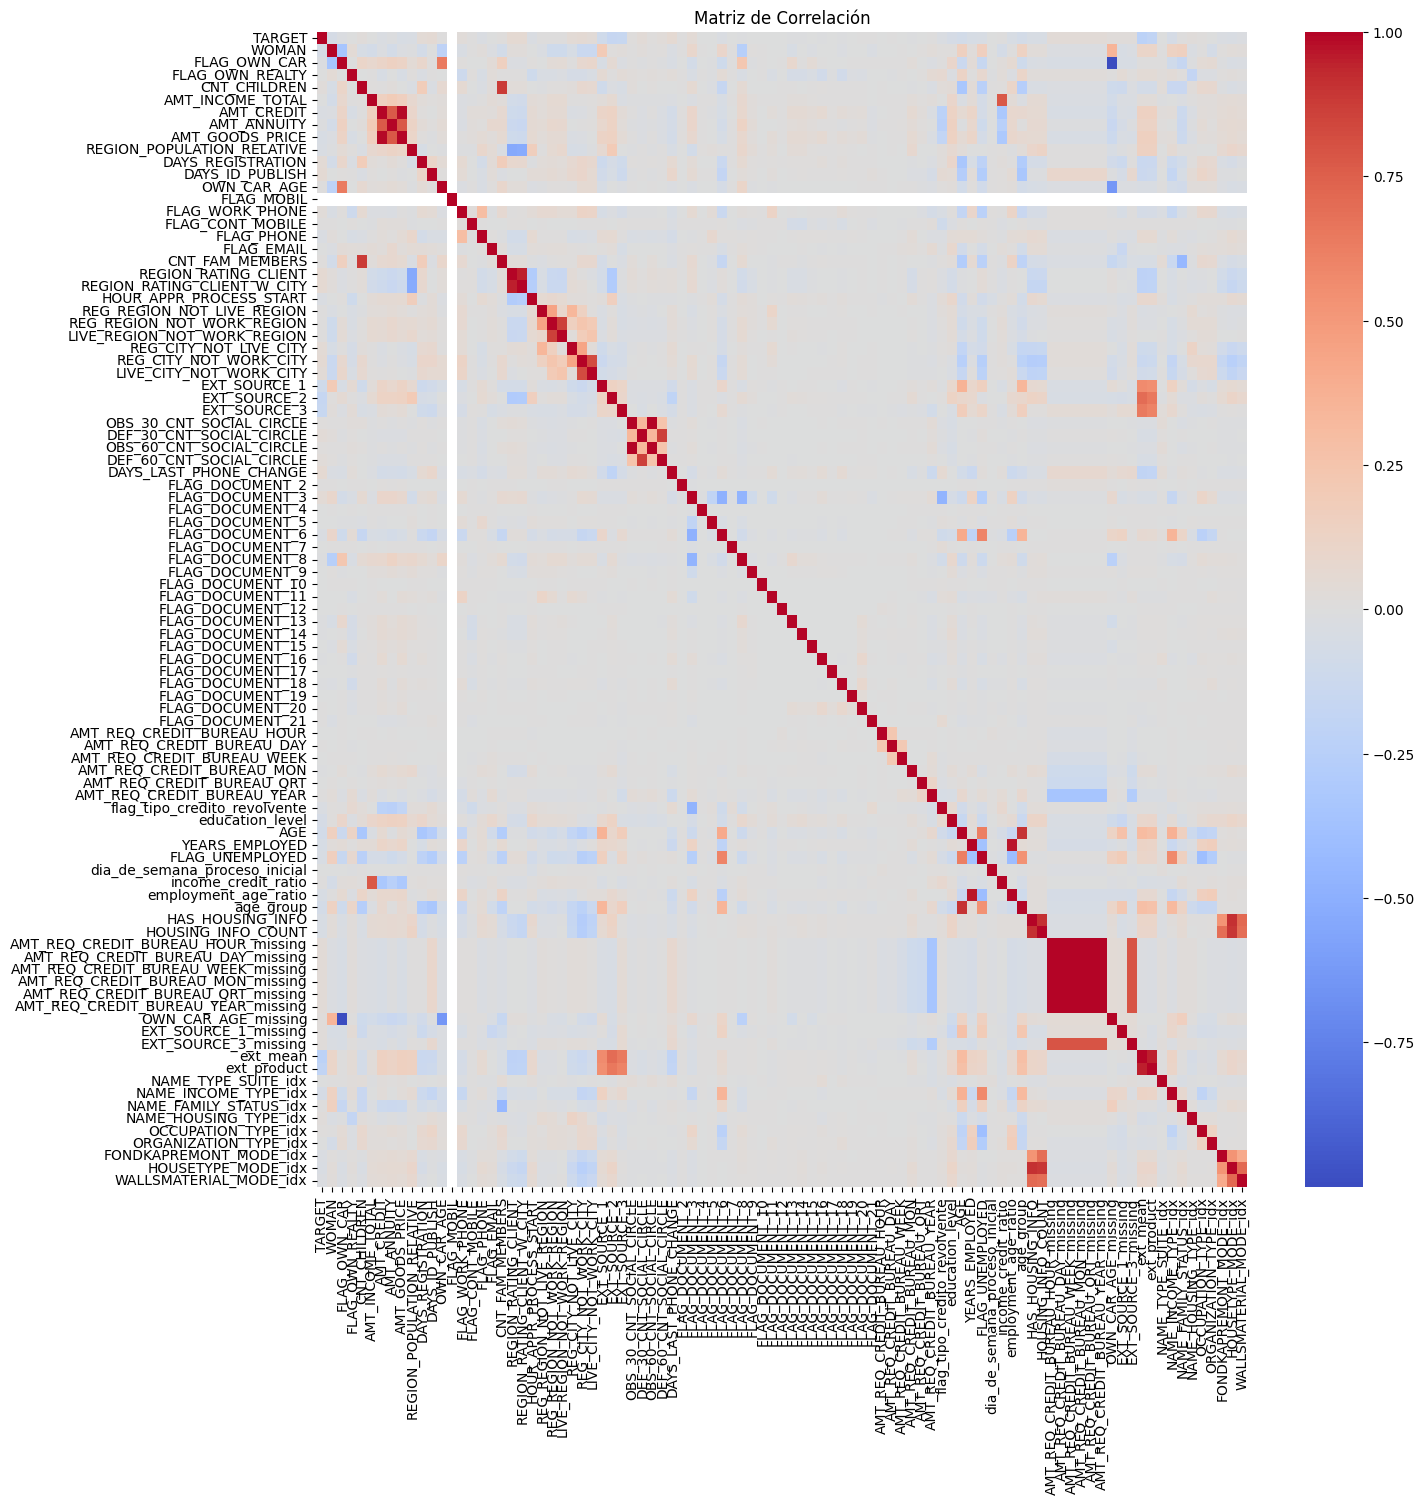

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

#Graficar correlacion
plt.figure(figsize=(15, 15))
sns.heatmap(corr_array, annot=False, cmap="coolwarm", xticklabels=num_cols, yticklabels=num_cols)
plt.title("Matriz de Correlación")
plt.show()

In [57]:
import numpy as np

#Revisar variables con correlacion abs >=90%
high_corr_pairs = []

for i in range(len(num_cols)):
    for j in range(i):
        corr_value = corr_array[i, j]

        if abs(corr_value) > 0.95:
            high_corr_pairs.append(
                (num_cols[i], num_cols[j], corr_value)
            )


for col1, col2, corr in high_corr_pairs:
    print(f"{col1}  -  {col2}  ->  {corr:.3f}")


AMT_GOODS_PRICE  -  AMT_CREDIT  ->  0.987
REGION_RATING_CLIENT_W_CITY  -  REGION_RATING_CLIENT  ->  0.951
OBS_60_CNT_SOCIAL_CIRCLE  -  OBS_30_CNT_SOCIAL_CIRCLE  ->  0.998
employment_age_ratio  -  YEARS_EMPLOYED  ->  0.964
AMT_REQ_CREDIT_BUREAU_DAY_missing  -  AMT_REQ_CREDIT_BUREAU_HOUR_missing  ->  1.000
AMT_REQ_CREDIT_BUREAU_WEEK_missing  -  AMT_REQ_CREDIT_BUREAU_HOUR_missing  ->  1.000
AMT_REQ_CREDIT_BUREAU_WEEK_missing  -  AMT_REQ_CREDIT_BUREAU_DAY_missing  ->  1.000
AMT_REQ_CREDIT_BUREAU_MON_missing  -  AMT_REQ_CREDIT_BUREAU_HOUR_missing  ->  1.000
AMT_REQ_CREDIT_BUREAU_MON_missing  -  AMT_REQ_CREDIT_BUREAU_DAY_missing  ->  1.000
AMT_REQ_CREDIT_BUREAU_MON_missing  -  AMT_REQ_CREDIT_BUREAU_WEEK_missing  ->  1.000
AMT_REQ_CREDIT_BUREAU_QRT_missing  -  AMT_REQ_CREDIT_BUREAU_HOUR_missing  ->  1.000
AMT_REQ_CREDIT_BUREAU_QRT_missing  -  AMT_REQ_CREDIT_BUREAU_DAY_missing  ->  1.000
AMT_REQ_CREDIT_BUREAU_QRT_missing  -  AMT_REQ_CREDIT_BUREAU_WEEK_missing  ->  1.000
AMT_REQ_CREDIT_BUREAU_Q

In [58]:
df_dropna = df_dropna.drop("REGION_RATING_CLIENT","OWN_CAR_AGE_missing") #Eliminar variable correlacionada

In [59]:
df_dropna.show(10)

+------+-----+------------+---------------+------------+----------------+----------+-----------+---------------+--------------------------+-----------------+---------------+-----------+----------+---------------+----------------+----------+----------+---------------+---------------------------+-----------------------+--------------------------+--------------------------+---------------------------+----------------------+----------------------+-----------------------+-------------------+-------------------+-------------------+------------------------+------------------------+------------------------+------------------------+----------------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+--------------

##Random Forest

In [60]:
from pyspark.ml.classification import RandomForestClassifier

num_cols_2 = [f.name for f in df_dropna.schema.fields
            if isinstance(f.dataType,(IntegerType,DoubleType))]

num_cols_2.remove("TARGET")

print(num_cols_2)
assembler_2 = VectorAssembler(inputCols=num_cols_2,outputCol="variables")
df_vector_2 = assembler_2.transform(df_dropna)

df_vector_2.select('variables').show(100, False)

['WOMAN', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 

In [61]:
from pyspark.ml.classification import RandomForestClassifier


rf = RandomForestClassifier(
    labelCol="TARGET",
    featuresCol="variables",
    numTrees=100,
    maxBins=64
)

model = rf.fit(df_vector_2)

In [62]:
#Ver importancia de cada variable

import pandas as pd

importancia = model.featureImportances.toArray()

feature_importances = pd.DataFrame({
    "variables": num_cols_2,
    "importancia": importancia
}).sort_values(by="importancia", ascending=False)


In [63]:
feature_importances.head(100)

,variables,importancia
79,ext_mean,0.186343
27,EXT_SOURCE_2,0.141528
26,EXT_SOURCE_1,0.121573
80,ext_product,0.102671
28,EXT_SOURCE_3,0.087049
...,...,...
65,dia_de_semana_proceso_inicial,0.000000
76,AMT_REQ_CREDIT_BUREAU_YEAR_missing,0.000000
77,EXT_SOURCE_1_missing,0.000000
83,NAME_FAMILY_STATUS_idx,0.000000


In [64]:
#Seleccionar variables Top 10 de importancia

selected_features = feature_importances.head(10)["variables"].tolist()
selected_features

['ext_mean',
 'EXT_SOURCE_2',
 'EXT_SOURCE_1',
 'ext_product',
 'EXT_SOURCE_3',
 'AGE',
 'age_group',
 'AMT_GOODS_PRICE',
 'education_level',
 'WOMAN']

In [65]:

selected_features = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'education_level',
    'AMT_GOODS_PRICE',
    'AGE',
    'NAME_INCOME_TYPE_idx',
    'WOMAN',
    'REG_CITY_NOT_LIVE_CITY',
    'YEARS_EMPLOYED',

    # nuevas
    'income_credit_ratio',
    'employment_age_ratio',
    'ext_mean',
    'ext_product',
    'age_group'
]

selected_features

['EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'education_level',
 'AMT_GOODS_PRICE',
 'AGE',
 'NAME_INCOME_TYPE_idx',
 'WOMAN',
 'REG_CITY_NOT_LIVE_CITY',
 'YEARS_EMPLOYED',
 'income_credit_ratio',
 'employment_age_ratio',
 'ext_mean',
 'ext_product',
 'age_group']

#Ejecución de modelo

In [66]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

#Crear dataframe solo de las variables seleccionadas
df_selected = df_dropna.select(["TARGET"] + selected_features)
df_selected.show(10)

+------+-------------------+-------------------+-------------------+---------------+---------------+---+--------------------+-----+----------------------+--------------+-------------------+--------------------+-------------------+--------------------+---------+
|TARGET|       EXT_SOURCE_1|       EXT_SOURCE_2|       EXT_SOURCE_3|education_level|AMT_GOODS_PRICE|AGE|NAME_INCOME_TYPE_idx|WOMAN|REG_CITY_NOT_LIVE_CITY|YEARS_EMPLOYED|income_credit_ratio|employment_age_ratio|           ext_mean|         ext_product|age_group|
+------+-------------------+-------------------+-------------------+---------------+---------------+---+--------------------+-----+----------------------+--------------+-------------------+--------------------+-------------------+--------------------+---------+
|     1|0.08303696739132256| 0.2629485927471776|0.13937578009978951|              1|       351000.0| 25|                 0.0|    0|                     0|             1| 0.5769230769230769|                0.04|0.16

In [67]:
#Crear vector con las variables seleccionadas
assembler_selection = VectorAssembler(
    inputCols=selected_features,
    outputCol="features"
)

df_final = assembler_selection.transform(df_selected)

In [68]:
#Entrenamiento/Prueba
train,test = df_final.randomSplit([0.7,0.3], seed=42)

rf_2 = RandomForestClassifier(
    labelCol="TARGET",
    featuresCol="features",
    numTrees=100,
    maxBins=64,
    seed=42
)

model_2= rf_2.fit(train)

In [69]:
#Obtener predicciones para poder evaluar el modelo
predictions = model_2.transform(test)

In [70]:
from pyspark.sql.functions import col
from pyspark.ml.functions import vector_to_array

predictions = predictions.withColumn(
    "prob_1",
    vector_to_array(col("probability"))[1]
)

predictions.select("probability", "prob_1").show(10, False)

+----------------------------------------+-------------------+
|probability                             |prob_1             |
+----------------------------------------+-------------------+
|[0.854792139373975,0.145207860626025]   |0.145207860626025  |
|[0.8454429782463618,0.15455702175363817]|0.15455702175363817|
|[0.8755628659493309,0.12443713405066907]|0.12443713405066907|
|[0.8565448347898379,0.14345516521016213]|0.14345516521016213|
|[0.8752605352683407,0.1247394647316593] |0.1247394647316593 |
|[0.8435779946846331,0.15642200531536676]|0.15642200531536676|
|[0.8542938560131726,0.14570614398682735]|0.14570614398682735|
|[0.8613207618222889,0.13867923817771113]|0.13867923817771113|
|[0.846561269510589,0.153438730489411]   |0.153438730489411  |
|[0.8635653886269817,0.1364346113730182] |0.1364346113730182 |
+----------------------------------------+-------------------+
only showing top 10 rows


In [71]:
predictions.groupBy("prediction").count().orderBy("prediction").show()

predictions.show()

+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|91629|
+----------+-----+

+------+--------------------+--------------------+--------------------+---------------+---------------+---+--------------------+-----+----------------------+--------------+-------------------+--------------------+-------------------+--------------------+---------+--------------------+--------------------+--------------------+----------+-------------------+
|TARGET|        EXT_SOURCE_1|        EXT_SOURCE_2|        EXT_SOURCE_3|education_level|AMT_GOODS_PRICE|AGE|NAME_INCOME_TYPE_idx|WOMAN|REG_CITY_NOT_LIVE_CITY|YEARS_EMPLOYED|income_credit_ratio|employment_age_ratio|           ext_mean|         ext_product|age_group|            features|       rawPrediction|         probability|prediction|             prob_1|
+------+--------------------+--------------------+--------------------+---------------+---------------+---+--------------------+-----+----------------------+--------------+--------------

In [72]:
predictions.select("prob_1").describe().show()

+-------+--------------------+
|summary|              prob_1|
+-------+--------------------+
|  count|               91629|
|   mean| 0.08083683348284894|
| stddev|0.020981119032318144|
|    min| 0.06503059982971124|
|    max| 0.18941535341866855|
+-------+--------------------+



In [73]:
#Distribuciòn target en entrenamiento
train.groupBy("TARGET").count().show()

+------+------+
|TARGET| count|
+------+------+
|     1| 17277|
|     0|196635|
+------+------+



In [94]:
predictions.groupBy("TARGET").avg("prob_1").show()

+------+------------------+
|TARGET|       avg(prob_1)|
+------+------------------+
|     1|0.0972483252327127|
|     0|0.0793867196079566|
+------+------------------+



In [95]:
predictions.groupBy("TARGET", "prediction").count().show()

+------+----------+-----+
|TARGET|prediction|count|
+------+----------+-----+
|     1|       0.0| 7439|
|     0|       0.0|84190|
+------+----------+-----+



###Solucionar el mal resultado


In [75]:

from pyspark.sql.functions import when, col

#Crear variable de peso al target
train = train.withColumn(
    "weight",
    when(col("TARGET") == 1, 5).otherwise(1)
)

rf_3 = RandomForestClassifier(
    labelCol="TARGET",
    featuresCol="features",
    numTrees=100,
    maxDepth=10,
    minInstancesPerNode=50,
    weightCol="weight"
)


model_3= rf_3.fit(train)

In [76]:
model_3.featureImportances

SparseVector(15, {0: 0.0372, 1: 0.1029, 2: 0.1117, 3: 0.0218, 4: 0.0234, 5: 0.029, 6: 0.0174, 7: 0.0148, 8: 0.0026, 9: 0.0159, 10: 0.0151, 11: 0.02, 12: 0.3264, 13: 0.2512, 14: 0.0105})

In [77]:
#Obtener predicciones para poder evaluar el modelo
predictions_2 = model_3.transform(test)

In [78]:
predictions_2 = predictions_2.withColumn(
    "prob_1",
    vector_to_array(col("probability"))[1]
)

predictions_2.select("probability", "prob_1").show(10, False)

+----------------------------------------+------------------+
|probability                             |prob_1            |
+----------------------------------------+------------------+
|[0.3379726500351014,0.6620273499648986] |0.6620273499648986|
|[0.34479090230158926,0.6552090976984108]|0.6552090976984108|
|[0.39967516411999654,0.6003248358800035]|0.6003248358800035|
|[0.29415482230971884,0.7058451776902811]|0.7058451776902811|
|[0.4878418569735727,0.5121581430264274] |0.5121581430264274|
|[0.31964291206995804,0.680357087930042] |0.680357087930042 |
|[0.42227673032505036,0.5777232696749497]|0.5777232696749497|
|[0.47161743918321664,0.5283825608167834]|0.5283825608167834|
|[0.25901124663970726,0.7409887533602927]|0.7409887533602927|
|[0.3195619421457362,0.6804380578542638] |0.6804380578542638|
+----------------------------------------+------------------+
only showing top 10 rows


In [79]:
predictions_2.select("prob_1").describe().show()

+-------+-------------------+
|summary|             prob_1|
+-------+-------------------+
|  count|              91629|
|   mean|  0.269052483522463|
| stddev| 0.1459663743681627|
|    min|0.08527426762904848|
|    max| 0.7868106021714018|
+-------+-------------------+



In [80]:
predictions_2.groupBy("TARGET", "prediction").count().show()

+------+----------+-----+
|TARGET|prediction|count|
+------+----------+-----+
|     1|       0.0| 5163|
|     0|       0.0|77849|
|     1|       1.0| 2276|
|     0|       1.0| 6341|
+------+----------+-----+



In [81]:
from pyspark.sql.functions import when, sum as _sum

metrics_df = predictions_2.select(
    when((col("TARGET") == 1) & (col("prediction") == 1), 1).otherwise(0).alias("TP"),
    when((col("TARGET") == 0) & (col("prediction") == 0), 1).otherwise(0).alias("TN"),
    when((col("TARGET") == 0) & (col("prediction") == 1), 1).otherwise(0).alias("FP"),
    when((col("TARGET") == 1) & (col("prediction") == 0), 1).otherwise(0).alias("FN")
)

metrics = metrics_df.agg(
    _sum("TP").alias("TP"),
    _sum("TN").alias("TN"),
    _sum("FP").alias("FP"),
    _sum("FN").alias("FN")
)

metrics.show()

+----+-----+----+----+
|  TP|   TN|  FP|  FN|
+----+-----+----+----+
|2276|77849|6341|5163|
+----+-----+----+----+



In [82]:
metrics = metrics.collect()[0]

TP = metrics["TP"]
TN = metrics["TN"]
FP = metrics["FP"]
FN = metrics["FN"]

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision}") #Precision = qué tan confiables son los positivos
print(f"Recall: {recall}") #Recall = cuántos positivos detectas
print(f"F1 Score: {f1}") #F1 = balance entre precision y recall

Precision: 0.26412904723221536
Recall: 0.30595510149213606
F1 Score: 0.2835077229696064


In [83]:
predictions_2.groupBy("TARGET").avg("prob_1").show()

+------+------------------+
|TARGET|       avg(prob_1)|
+------+------------------+
|     1|0.3966194765786622|
|     0|0.2577807070484754|
+------+------------------+



In [84]:
from pyspark.sql.functions import when, sum as _sum

thresholds = [i/10 for i in range(1,10)]

results = []

for t in thresholds:

    temp = predictions_2.withColumn(
        "pred_t",
        when(col("prob_1") > t, 1).otherwise(0)
    )

    metrics_df = temp.select(
        when((col("TARGET") == 1) & (col("pred_t") == 1), 1).otherwise(0).alias("TP"),
        when((col("TARGET") == 0) & (col("pred_t") == 0), 1).otherwise(0).alias("TN"),
        when((col("TARGET") == 0) & (col("pred_t") == 1), 1).otherwise(0).alias("FP"),
        when((col("TARGET") == 1) & (col("pred_t") == 0), 1).otherwise(0).alias("FN")
    )

    m = metrics_df.agg(
        _sum("TP").alias("TP"),
        _sum("FP").alias("FP"),
        _sum("FN").alias("FN")
    ).collect()[0]

    TP, FP, FN = m["TP"], m["FP"], m["FN"]

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    results.append((t, precision, recall, f1))

In [85]:
for r in results:
    print(f"Threshold: {r[0]} | Precision: {r[1]:.3f} | Recall: {r[2]:.3f} | F1: {r[3]:.3f}")

Threshold: 0.1 | Precision: 0.082 | Recall: 0.997 | F1: 0.152
Threshold: 0.2 | Precision: 0.117 | Recall: 0.862 | F1: 0.205
Threshold: 0.3 | Precision: 0.161 | Recall: 0.655 | F1: 0.258
Threshold: 0.4 | Precision: 0.207 | Recall: 0.465 | F1: 0.286
Threshold: 0.5 | Precision: 0.264 | Recall: 0.306 | F1: 0.284
Threshold: 0.6 | Precision: 0.328 | Recall: 0.153 | F1: 0.208
Threshold: 0.7 | Precision: 0.443 | Recall: 0.044 | F1: 0.080
Threshold: 0.8 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.9 | Precision: 0.000 | Recall: 0.000 | F1: 0.000


In [86]:
best = max(results, key=lambda x: x[3])  # por F1

print(f"Mejor threshold: {best[0]}")
print(f"F1: {best[3]}")

Mejor threshold: 0.4
F1: 0.2860333347119401


In [87]:
best_t = best[0]

predictions_2 = predictions_2.withColumn(
    "final_pred",
    when(col("prob_1") > best_t, 1).otherwise(0)
)

In [88]:
predictions_2.groupBy("TARGET", "final_pred").count().show()

+------+----------+-----+
|TARGET|final_pred|count|
+------+----------+-----+
|     1|         0| 3981|
|     1|         1| 3458|
|     0|         0|70908|
|     0|         1|13282|
+------+----------+-----+



Precisión bajan(0.207), muchos falsos positivos.

Recall moderado (0.465), detecta casi la mitad de los clientes de riesgo.

F1 si separa las probabilidades.